# Sensor-set significance by terrain

Which proprioceptive sensor set carries a locomotion policy furthest, and is
the gap between two sets real? Bars are normalised max distance; letters above
them are a Compact Letter Display, so two bars sharing a letter are
statistically tied.

Figure geometry and fonts come from `paper_style.py` — edit that file to
restyle every figure in this folder at once.

In [1]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt

import paper_data as pdata
import paper_stats as pstats
from paper_style import (PAGE, H_SHORT, SENSORS, SENSOR_COLOR, SENSOR_LABEL,
                         TERRAIN_LABEL, grouped_bars, paper_rc, save_figure,
                         style_axes, swatch_legend)

TERRAINS = ["flat", "rough", "morph", "slope10", "slope_10", "mass1000"]

## Load rollouts

In [2]:
runs = pdata.load_terrains(SENSORS, TERRAINS)
print(f"{len(runs)} terrains x {len(SENSORS)} sensor sets x {pdata.N_POLICIES} policies")

6 terrains x 4 sensor sets x 5 policies


## Reference analysis: all policies pooled (n=150)

Scores are normalised per terrain, so the best single rollout on that terrain
scores 10. With n=150 per cell the normal approximation holds, so pairs are
compared with a Welch z-test and corrected with Holm over the whole family.

In [3]:
def show_cld(scores, letters):
    """Mean score and CLD letter for every terrain x sensor cell."""
    print("terrain".ljust(16) + "".join(SENSOR_LABEL[s].ljust(14) for s in SENSORS))
    for t in TERRAINS:
        row = TERRAIN_LABEL[t].ljust(16)
        for s in SENSORS:
            row += f"{scores[t][s].mean():.2f} ({letters[t][s]})".ljust(14)
        print(row)


scores = {t: pdata.normalize(pdata.by_sensor(runs[t])) for t in TERRAINS}

p_raw = pstats.pairwise_pvalues(scores, SENSORS, test=pstats.welch_z_pvalue)
p_holm = pstats.holm(p_raw)
pstats.report(p_raw, p_holm)

cld = pstats.letters_by_group(scores, SENSORS, p_holm)
print("\nCompact Letter Display (shared letter = not significantly different):\n")
show_cld(scores, cld)

family size m = 36
raw  p<0.05: 32 / 36
Holm p<0.05: 30 / 36

not significant after Holm:
      morph              vel vs vel_action      raw=0.6781  holm=1.0000
      rough       pos_action vs pos_vel_action  raw=0.9024  holm=1.0000
       flat       pos_action vs pos_vel_action  raw=0.2083  holm=0.6249
    slope10       pos_action vs pos_vel_action  raw=0.0948  holm=0.3793
   slope_10              vel vs vel_action      raw=0.0390  holm=0.1949
   slope_10       pos_action vs pos_vel_action  raw=0.0185  holm=0.1108

Compact Letter Display (shared letter = not significantly different):

terrain         pos+act       vel           vel+act       pos+vel+act   
Flat            9.47 (a)      8.01 (c)      8.30 (b)      9.43 (a)      
Rough           7.81 (a)      6.60 (c)      6.91 (b)      7.82 (a)      
Morph           8.10 (a)      6.80 (c)      6.75 (c)      7.73 (b)      
Slope Downhill  9.45 (a)      8.34 (c)      8.56 (b)      9.40 (a)      
Slope Uphill    8.33 (a)      7.72 (b)   

## Figure: policy 0

The figure reports a single policy, so the whole significance chain is
recomputed at n=30 — reusing the pooled letters above would attach n=150
conclusions to n=30 bars. At n=30 the test also switches from z to Welch t.

In [4]:
POLICY = 0

scores_p0 = {t: pdata.normalize(pdata.by_sensor(runs[t], policy=POLICY)) for t in TERRAINS}
print(f"policy {POLICY}: n={scores_p0['flat']['vel'].size} per sensor per terrain\n")

p_raw_p0 = pstats.pairwise_pvalues(scores_p0, SENSORS, test=pstats.welch_t_pvalue)
p_holm_p0 = pstats.holm(p_raw_p0)
pstats.report(p_raw_p0, p_holm_p0)

cld_p0 = pstats.letters_by_group(scores_p0, SENSORS, p_holm_p0)
print("\nCompact Letter Display, policy 0:\n")
show_cld(scores_p0, cld_p0)

means, errors = {}, {}
for t in TERRAINS:
    for s in SENSORS:
        means[(t, s)], errors[(t, s)] = pstats.mean_ci(scores_p0[t][s])

policy 0: n=30 per sensor per terrain

family size m = 36
raw  p<0.05: 31 / 36
Holm p<0.05: 29 / 36

not significant after Holm:
      morph              vel vs vel_action      raw=0.2390  holm=0.9560
       flat       pos_action vs pos_vel_action  raw=0.2939  holm=0.9560
      rough       pos_action vs pos_vel_action  raw=0.3031  holm=0.9560
   slope_10       vel_action vs pos_vel_action  raw=0.3454  holm=0.9560
   slope_10       pos_action vs vel_action      raw=0.1037  holm=0.5184
   slope_10       pos_action vs pos_vel_action  raw=0.0257  holm=0.1543
      morph       pos_action vs pos_vel_action  raw=0.0075  holm=0.0524

Compact Letter Display, policy 0:

terrain         pos+act       vel           vel+act       pos+vel+act   
Flat            9.61 (a)      7.42 (c)      8.35 (b)      9.55 (a)      
Rough           8.68 (a)      5.85 (c)      7.25 (b)      8.47 (a)      
Morph           8.74 (a)      7.62 (b)      7.40 (b)      8.21 (a)      
Slope Downhill  9.64 (a)      7.75 (d) 

Saved -> local_prop_cld_by_terrain_policy0.pdf, local_prop_cld_by_terrain_policy0.png


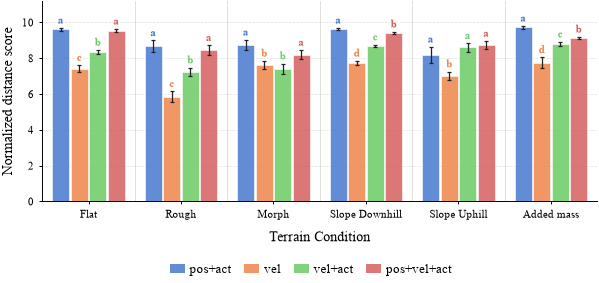

In [5]:
with paper_rc():
    fig, ax = plt.subplots(figsize=(PAGE, H_SHORT))

    at = grouped_bars(ax, TERRAINS, SENSORS, means, errors,
                      colors=[SENSOR_COLOR[s] for s in SENSORS])

    # Compact Letter Display above each bar
    for (t, s), x in at.items():
        ax.text(x, means[(t, s)] + errors[(t, s)] + 0.10, cld_p0[t][s],
                ha="center", va="bottom", fontsize=8,
                color=SENSOR_COLOR[s], fontweight="bold", zorder=6)

    for k in range(1, len(TERRAINS)):        # terrain separators
        ax.axvline(k - 0.5, color="#e1e0d9", lw=0.7, zorder=0)

    ax.set_xticks(range(len(TERRAINS)))
    ax.set_xticklabels([TERRAIN_LABEL[t] for t in TERRAINS])
    ax.set_xlabel("Terrain Condition", labelpad=8)
    ax.set_ylabel("Normalized distance score", labelpad=5)
    ax.set_xlim(-0.5, len(TERRAINS) - 0.5)
    ax.set_ylim(0, max(means[k] + errors[k] for k in means) * 1.14)
    style_axes(ax)

    swatch_legend(fig, [SENSOR_LABEL[s] for s in SENSORS],
                  [SENSOR_COLOR[s] for s in SENSORS])

    save_figure(fig, f"local_prop_cld_by_terrain_policy{POLICY}")
    plt.show()